<a href="https://colab.research.google.com/github/Amthi/NLP_/blob/main/NLP_Practical_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
!pip install gensim wordcloud --quiet
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [41]:
#libraries
import re, time, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
import spacy
from wordcloud import WordCloud

from sklearn.model_selection         import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.decomposition           import PCA
from sklearn.manifold                import TSNE
from sklearn.metrics.pairwise        import cosine_similarity
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec

for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet']:
    nltk.download(pkg, quiet=True)

random.seed(42); np.random.seed(42)
sns.set_style('whitegrid')

## Task 1 - Preprocessing and Exploratory Analysis

In [42]:
#file path for connect csv file ( dataset )
tweets_df_original = pd.read_csv('/content/Tweets.csv')
tweets_df = tweets_df_original[['tweet_id','airline_sentiment','airline_sentiment_confidence','airline','negativereason','text']].dropna(subset=['text','airline_sentiment'])
print('Raw shape:', tweets_df.shape)
tweets_df.head()

Raw shape: (14640, 6)


,tweet_id,airline_sentiment,airline_sentiment_confidence,airline,negativereason,text
0,570306133677760513,neutral,1.0000,Virgin America,NaN,@VirginAmerica What @dhepburn said.
1,570301130888122368,positive,0.3486,Virgin America,NaN,@VirginAmerica plus you've added commercials to the experience... tacky.
2,570301083672813571,neutral,0.6837,Virgin America,NaN,@VirginAmerica I didn't today... Must mean I need to take another trip!
3,570301031407624196,negative,1.0000,Virgin America,Bad Flight,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl..."
4,570300817074462722,negative,1.0000,Virgin America,Can't Tell,@VirginAmerica and it's a really big bad thing about it


In [43]:
#duplicates
print('Duplicate tweet_ids:', tweets_df['tweet_id'].duplicated().sum())
print('Duplicate texts    :', tweets_df['text'].duplicated().sum())
tweets_df = tweets_df.drop_duplicates(subset='tweet_id').drop_duplicates(subset='text').reset_index(drop=True)
print('Shape after removing duplicates:', tweets_df.shape)

Duplicate tweet_ids: 155
Duplicate texts    : 213
Shape after removing duplicates: (14427, 6)


airline_sentiment
negative    9080
neutral     3057
positive    2290
Name: count, dtype: int64
airline_sentiment
negative    62.9
neutral     21.2
positive    15.9
Name: proportion, dtype: float64


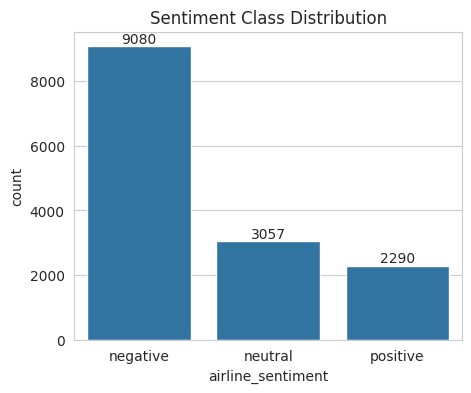

In [44]:
#target variable
print(tweets_df['airline_sentiment'].value_counts())
print((tweets_df['airline_sentiment'].value_counts(normalize=True) * 100).round(1))
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='airline_sentiment', data=tweets_df, order=['negative','neutral','positive'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.title('Sentiment Class Distribution')
plt.show()

In [45]:
#label quality - share of labels with low annotator confidence (< 0.7)
low_conf = tweets_df.groupby('airline_sentiment')['airline_sentiment_confidence'].apply(lambda s: (s < 0.7).mean())
print('Share of labels with confidence < 0.7:')
print((low_conf * 100).round(1))

print('\nMost common @handle per airline label:')
for a in tweets_df['airline'].unique():
    h = tweets_df.loc[tweets_df['airline'] == a, 'text'].str.extract(r'^(@\w+)')[0].str.lower().value_counts()
    print(f'  {a:15s} -> {h.index[0]} ({h.iloc[0]} tweets)')

Share of labels with confidence < 0.7:
airline_sentiment
negative    17.8
neutral     47.4
positive    32.9
Name: airline_sentiment_confidence, dtype: float64

Most common @handle per airline label:
  Virgin America  -> @virginamerica (486 tweets)
  United          -> @united (3709 tweets)
  Southwest       -> @southwestair (2369 tweets)
  Delta           -> @jetblue (1988 tweets)
  US Airways      -> @usairways (2857 tweets)
  American        -> @americanair (2533 tweets)


In [46]:
#text cleaning
def basic_clean(t):
    t = re.sub(r'http\S+|www\.\S+', ' ', str(t))    # urls
    t = re.sub(r'@\w+', ' ', t)                       # mentions
    t = re.sub(r'#(\w+)', r'\1', t)                   # hashtags -> word
    t = re.sub(r"[^A-Za-z\s']", ' ', t)               # numbers, punctuation, emoji
    return re.sub(r'\s+', ' ', t).strip().lower()

#light cleaning for NER - keep capital letters and punctuation
def ner_clean(t):
    t = re.sub(r'http\S+|www\.\S+', ' ', str(t))
    t = re.sub(r'@\w+', ' ', t).replace('#', '').replace('&amp;', '&')
    return re.sub(r'\s+', ' ', t).strip()

tweets_df['clean_text'] = tweets_df['text'].apply(basic_clean)
tweets_df['ner_text']   = tweets_df['text'].apply(ner_clean)
tweets_df['review_len'] = tweets_df['text'].apply(lambda x: len(str(x).split()))
print('Empty tweets after cleaning:', (tweets_df['clean_text'] == '').sum())
print(tweets_df[['text','clean_text']].head(5).to_string())

Empty tweets after cleaning: 0
                                                                                                                             text                                                                                                   clean_text
0                                                                                             @VirginAmerica What @dhepburn said.                                                                                                    what said
1                                                        @VirginAmerica plus you've added commercials to the experience... tacky.                                                        plus you've added commercials to the experience tacky
2                                                         @VirginAmerica I didn't today... Must mean I need to take another trip!                                                         i didn't today must mean i need to take another trip
3  @VirginAme

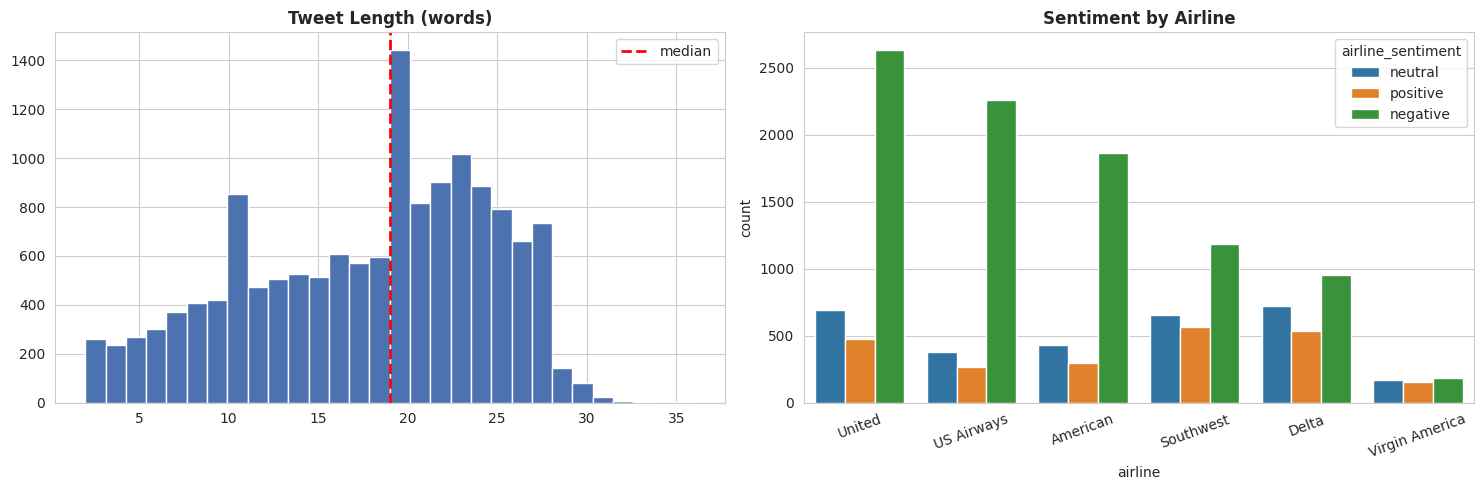

airline_sentiment  negative  neutral  positive
airline                                       
American               71.9     16.6      11.5
Delta                  43.2     32.7      24.1
Southwest              49.2     27.3      23.5
US Airways             77.8     13.1       9.1
United                 69.2     18.2      12.6
Virgin America         36.0     34.0      30.0


In [47]:
#tweet length + sentiment by airline
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].hist(tweets_df['review_len'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(tweets_df['review_len'].median(), color='red', linestyle='dashed', linewidth=2, label='median')
axes[0].set_title('Tweet Length (words)', fontweight='bold'); axes[0].legend()
sns.countplot(x='airline', hue='airline_sentiment', data=tweets_df,
              order=tweets_df['airline'].value_counts().index, ax=axes[1])
axes[1].set_title('Sentiment by Airline', fontweight='bold'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
print((pd.crosstab(tweets_df['airline'], tweets_df['airline_sentiment'], normalize='index') * 100).round(1))

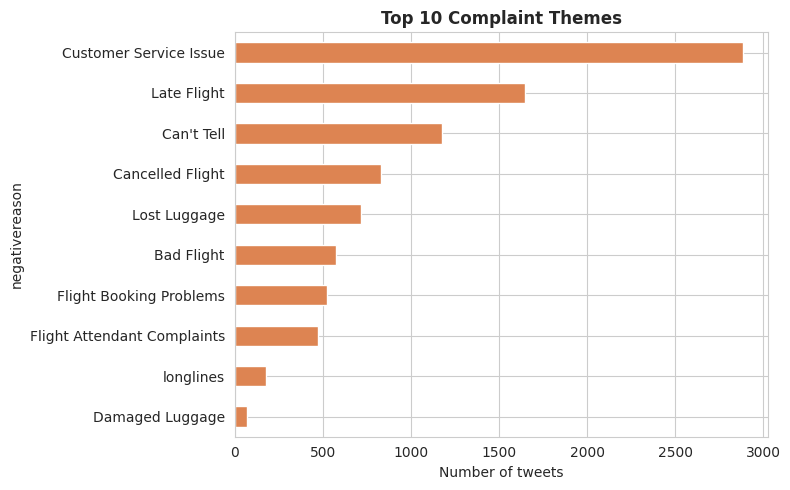

negativereason
Customer Service Issue         31.8
Late Flight                    18.2
Can't Tell                     13.0
Cancelled Flight                9.1
Lost Luggage                    7.9
Bad Flight                      6.3
Flight Booking Problems         5.8
Flight Attendant Complaints     5.2
longlines                       1.9
Damaged Luggage                 0.8


In [48]:
#complaint themes (negative reasons)
neg_reason = tweets_df['negativereason'].value_counts().head(10)
plt.figure(figsize=(8, 5))
neg_reason.sort_values().plot(kind='barh', color='#DD8452')
plt.title('Top 10 Complaint Themes', fontweight='bold')
plt.xlabel('Number of tweets')
plt.tight_layout()
plt.show()
print((neg_reason / neg_reason.sum() * 100).round(1).to_string())

In [49]:
#NLTK pipeline (2,000-tweet sample)
sample = tweets_df.sample(2000, random_state=42).reset_index(drop=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nltk_pipeline(text):
    tokens = word_tokenize(text)
    tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 1]
    lemmas = [lemmatizer.lemmatize(lemmatizer.lemmatize(t, pos='v'), pos='n') for t in tokens_nostop]
    return tokens, lemmas

t0 = time.time()
nltk_out = [nltk_pipeline(t) for t in sample['clean_text']]
nltk_time = time.time() - t0
nltk_tokens_all = [o[0] for o in nltk_out]
nltk_lemmas_all = [o[1] for o in nltk_out]
nltk_total_tokens = sum(len(t) for t in nltk_tokens_all)
nltk_vocab = set(w for doc in nltk_lemmas_all for w in doc)
print(f'NLTK  time: {nltk_time:.2f}s | tokens: {nltk_total_tokens:,} | vocabulary: {len(nltk_vocab):,}')

NLTK  time: 1.17s | tokens: 33,149 | vocabulary: 3,172


In [50]:
#spaCy pipeline (same 2,000 tweets)
nlp = spacy.load('en_core_web_sm', disable=['parser'])
t0 = time.time()
spacy_tokens_all, spacy_lemmas_all = [], []
for doc in nlp.pipe(sample['clean_text'].tolist(), batch_size=64):
    spacy_tokens_all.append([tok.text for tok in doc])
    spacy_lemmas_all.append([tok.lemma_ for tok in doc if not tok.is_stop and not tok.is_punct and len(tok.text) > 1])
spacy_time = time.time() - t0
spacy_total_tokens = sum(len(t) for t in spacy_tokens_all)
spacy_vocab = set(w for doc in spacy_lemmas_all for w in doc)
print(f'spaCy time: {spacy_time:.2f}s | tokens: {spacy_total_tokens:,} | vocabulary: {len(spacy_vocab):,}')

#lemma examples
demo_words = ['flights', 'flying', 'delayed', 'cancelled', 'worse', 'better', 'leaving', 'mice', 'was', 'studies']
print('\nLemma comparison:')
for w, d in zip(demo_words, nlp.pipe(demo_words)):
    print(f'  {w:10s} -> NLTK: {lemmatizer.lemmatize(lemmatizer.lemmatize(w, pos="v"), pos="n"):8s} | spaCy: {d[0].lemma_}')

spaCy time: 17.05s | tokens: 33,207 | vocabulary: 3,103

Lemma comparison:
  flights    -> NLTK: flight   | spaCy: flight
  flying     -> NLTK: fly      | spaCy: fly
  delayed    -> NLTK: delay    | spaCy: delay
  cancelled  -> NLTK: cancel   | spaCy: cancel
  worse      -> NLTK: worse    | spaCy: bad
  better     -> NLTK: better   | spaCy: well
  leaving    -> NLTK: leave    | spaCy: leave
  mice       -> NLTK: mouse    | spaCy: mouse
  was        -> NLTK: be       | spaCy: be
  studies    -> NLTK: study    | spaCy: study


             lower-cased  case-preserved
ORG                   66             530
CARDINAL              73             402
DATE                 254             344
TIME                 250             307
GPE                  144             230
PERSON                78             189
ORDINAL               30              57
MONEY                  2              47
PRODUCT                0              45
NORP                  24              27
LOC                    3              25
WORK_OF_ART            0              25
QUANTITY               3              16
FAC                    7              14
EVENT                  0               4
LAW                    0               2
LANGUAGE               1               1

Entity examples:
  ORG      : ['😃', 'US Air', 'CC', 'PHX - BOS', 'delta airways']
  CARDINAL : ['10', '100', 'one', '103', 'At least one']
  DATE     : ['tomorrow', '90+', 'the past couple of weeks', '2 days &', '6-year-old']
  TIME     : ['10 hours', 'tonight'

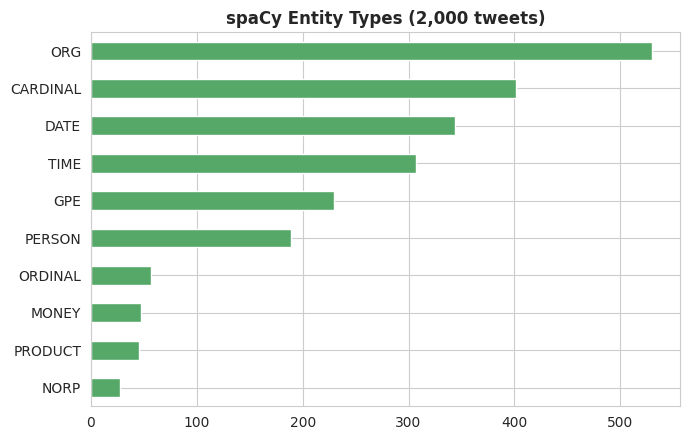

In [51]:
#NER - lower-cased text vs case-preserved text
def run_ner(texts):
    ents = [[(e.text, e.label_) for e in doc.ents] for doc in nlp.pipe(texts, batch_size=64)]
    return ents, Counter(lab for doc in ents for _, lab in doc)

ents_lower, labels_lower = run_ner(sample['clean_text'].tolist())
ents_cased, labels_cased = run_ner(sample['ner_text'].tolist())
ner_compare = pd.DataFrame({'lower-cased': labels_lower, 'case-preserved': labels_cased}).fillna(0).astype(int)
ner_compare = ner_compare.sort_values('case-preserved', ascending=False)
print(ner_compare.to_string())

examples = {}
for doc in ents_cased:
    for text, lab in doc:
        examples.setdefault(lab, [])
        if len(examples[lab]) < 5 and text not in examples[lab]:
            examples[lab].append(text)
print('\nEntity examples:')
for lab in ner_compare.index[:8]:
    print(f'  {lab:9s}: {examples.get(lab, [])}')

ner_compare['case-preserved'].head(10).sort_values().plot(kind='barh', figsize=(7,4.5), color='#55A868')
plt.title('spaCy Entity Types (2,000 tweets)', fontweight='bold')
plt.tight_layout()
plt.show()

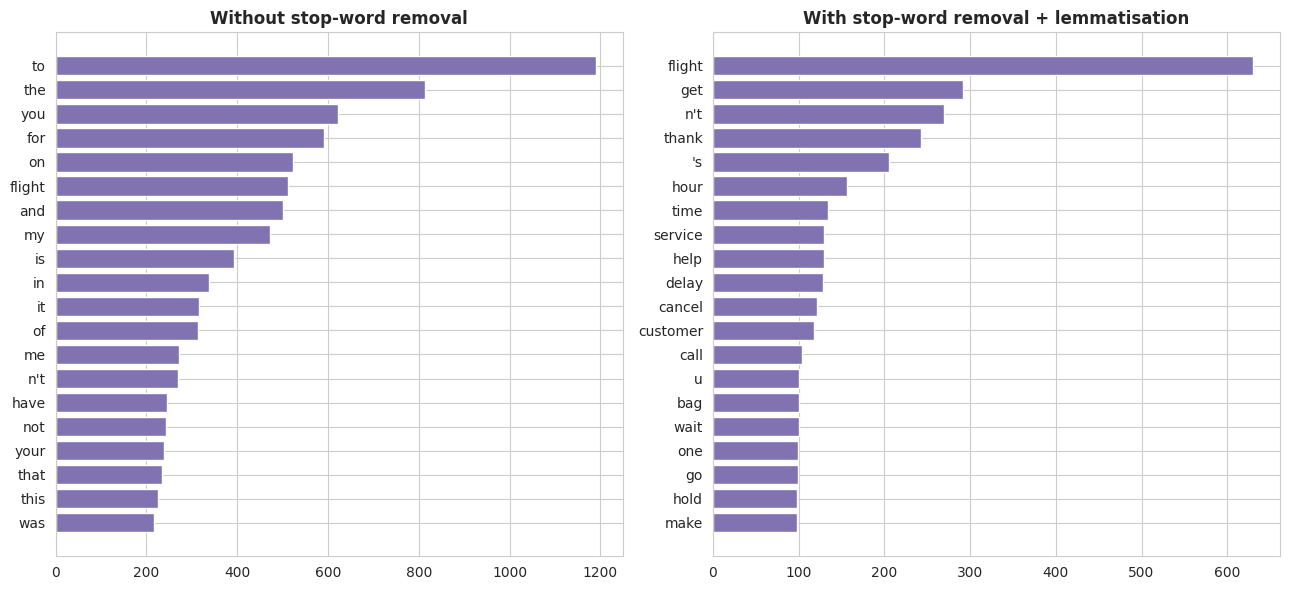

Negations inside the NLTK stop-word list: ["couldn't", "didn't", "don't", "isn't", 'no', 'nor', 'not', "wasn't", "won't"]
Tweets that lose a negation word when stop words are removed: 24.3%


In [52]:
#stop words - with vs without removal
flat_raw    = [w for doc in nltk_tokens_all for w in doc if len(w) > 1]
flat_lemmas = [w for doc in nltk_lemmas_all for w in doc]
fig, axes = plt.subplots(1, 2, figsize=(13,6))
for ax, toks, title in [(axes[0], flat_raw, 'Without stop-word removal'),
                        (axes[1], flat_lemmas, 'With stop-word removal + lemmatisation')]:
    w_, c_ = zip(*Counter(toks).most_common(20))
    ax.barh(list(w_)[::-1], list(c_)[::-1], color='#8172B2')
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

negations = {'not', 'no', 'nor', "don't", "didn't", "isn't", "wasn't", "won't", "couldn't"} & stop_words
neg_share = sample['clean_text'].apply(lambda t: any(w in negations for w in t.split())).mean()
print('Negations inside the NLTK stop-word list:', sorted(negations))
print(f'Tweets that lose a negation word when stop words are removed: {neg_share:.1%}')

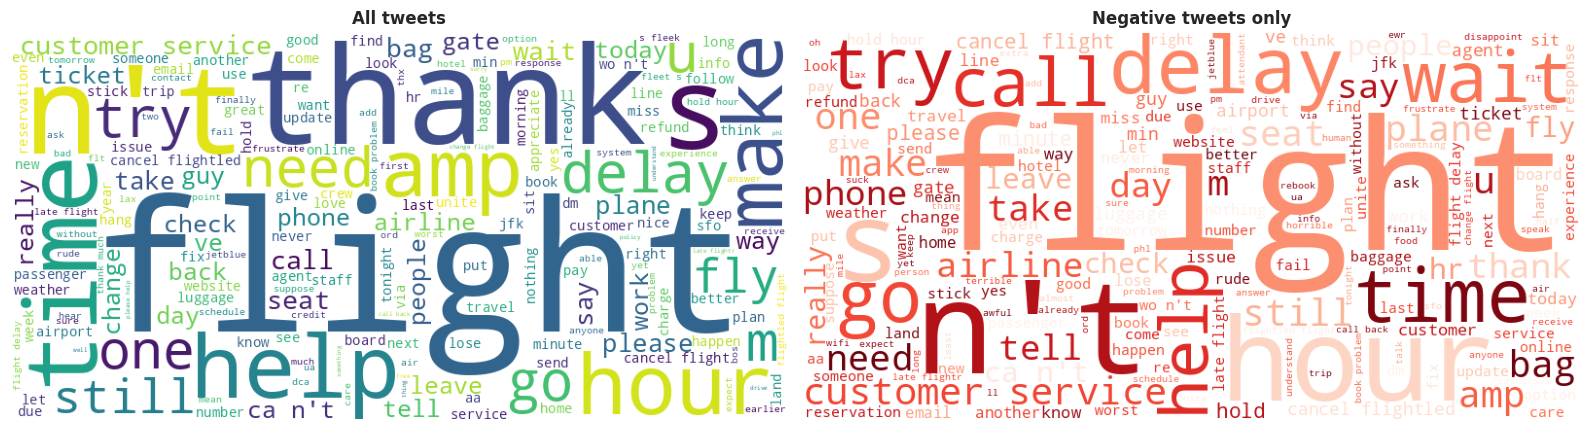

In [53]:
#word clouds
fig, axes = plt.subplots(1, 2, figsize=(16,5))
neg_lemmas = [w for doc, s in zip(nltk_lemmas_all, sample['airline_sentiment']) if s == 'negative' for w in doc]
for ax, words, title, cmap in [(axes[0], flat_lemmas, 'All tweets', 'viridis'),
                               (axes[1], neg_lemmas, 'Negative tweets only', 'Reds')]:
    ax.imshow(WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(' '.join(words)))
    ax.axis('off'); ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
#NLTK vs spaCy comparison table
comp_df = pd.DataFrame({
    'Metric': ['Components', 'Time (2,000 tweets)', 'Total tokens', 'Vocabulary after lemmatisation',
               'Lemma examples', 'NER', 'Lemmatisation approach'],
    'NLTK':  ['word_tokenize, stopwords, WordNetLemmatizer', f'{nltk_time:.2f}s', f'{nltk_total_tokens:,}',
              f'{len(nltk_vocab):,}', 'better->better, worse->worse', 'Not built-in',
              'Rule-based WordNet, needs POS hint'],
    'spaCy': ['tokenizer, tagger, lemmatizer, NER', f'{spacy_time:.2f}s', f'{spacy_total_tokens:,}',
              f'{len(spacy_vocab):,}', 'better->well, worse->bad', f'Built-in, {len(labels_cased)} entity types',
              'Statistical, uses predicted POS']})
comp_df

,Metric,NLTK,spaCy
0,Components,"word_tokenize, stopwords, WordNetLemmatizer","tokenizer, tagger, lemmatizer, NER"
1,"Time (2,000 tweets)",1.17s,17.05s
2,Total tokens,"33,149","33,207"
3,Vocabulary after lemmatisation,"3,172","3,103"
4,Lemma examples,"better->better, worse->worse","better->well, worse->bad"
5,NER,Not built-in,"Built-in, 17 entity types"
6,Lemmatisation approach,"Rule-based WordNet, needs POS hint","Statistical, uses predicted POS"


## Task 2 - Classical Baseline (TF-IDF + Logistic Regression / Linear SVM)


In [55]:
#train / test split + TF-IDF
X = tweets_df['clean_text']
y = tweets_df['airline_sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print('TF-IDF matrix:', X_train_tfidf.shape)

Train shape: (11541,)
Test shape : (2886,)
TF-IDF matrix: (11541, 8000)


In [56]:
#models
t0 = time.time()
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(X_train_tfidf, y_train)
lr_time = time.time() - t0
svm = LinearSVC(class_weight='balanced', random_state=42).fit(X_train_tfidf, y_train)
pred_lr  = logreg.predict(X_test_tfidf)
pred_svm = svm.predict(X_test_tfidf)

print(f'Logistic Regression (trained in {lr_time:.2f}s)')
print(classification_report(y_test, pred_lr, digits=3))
print('Linear SVM')
print(classification_report(y_test, pred_svm, digits=3))

Logistic Regression (trained in 3.25s)
              precision    recall  f1-score   support

    negative      0.896     0.818     0.855      1816
     neutral      0.579     0.696     0.632       612
    positive      0.716     0.771     0.742       458

    accuracy                          0.784      2886
   macro avg      0.730     0.762     0.743      2886
weighted avg      0.800     0.784     0.790      2886

Linear SVM
              precision    recall  f1-score   support

    negative      0.870     0.860     0.865      1816
     neutral      0.600     0.632     0.616       612
    positive      0.742     0.723     0.732       458

    accuracy                          0.790      2886
   macro avg      0.737     0.738     0.738      2886
weighted avg      0.793     0.790     0.791      2886



                     Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
Logistic Regression    0.7845             0.7303          0.7615      0.7432
Linear SVM             0.7900             0.7374          0.7384      0.7377


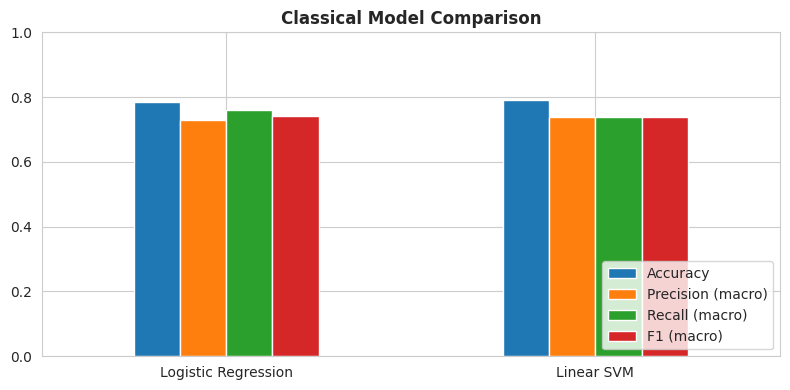

In [57]:
#results table
results = {}
for name, yp in [('Logistic Regression', pred_lr), ('Linear SVM', pred_svm)]:
    p, r, f, _ = precision_recall_fscore_support(y_test, yp, average='macro')
    results[name] = {'Accuracy': round(accuracy_score(y_test, yp), 4), 'Precision (macro)': round(p, 4),
                     'Recall (macro)': round(r, 4), 'F1 (macro)': round(f, 4)}
results_df = pd.DataFrame(results).T
print(results_df.to_string())

results_df.plot(kind='bar', figsize=(8,4), rot=0)
plt.ylim(0, 1); plt.title('Classical Model Comparison', fontweight='bold'); plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

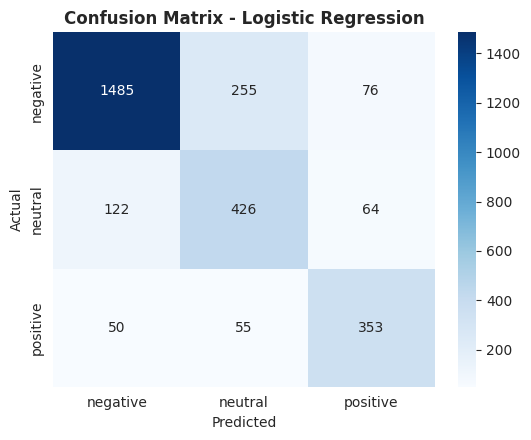

Negative predicted as neutral/positive: 331
Neutral/positive predicted as negative: 172


In [58]:
#confusion matrix - Logistic Regression
labels_order = ['negative', 'neutral', 'positive']
cm_lr = confusion_matrix(y_test, pred_lr, labels=labels_order)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()
print('Negative predicted as neutral/positive:', cm_lr[0,1] + cm_lr[0,2])
print('Neutral/positive predicted as negative:', cm_lr[1,0] + cm_lr[2,0])

In [59]:
#interpretability - strongest TF-IDF features per class
feat = np.array(tfidf.get_feature_names_out())
for i, cls in enumerate(logreg.classes_):
    print(f'{cls:8s}: {", ".join(feat[np.argsort(-logreg.coef_[i])[:12]])}')

negative: not, no, hours, delayed, worst, cancelled, your, hrs, why, nothing, on hold, hour
neutral : is there, hi, can you, or, question, do you, is your, dm, can, do, okay, if
positive: great, thanks, awesome, love, thank, amazing, thank you, thx, best, good, excellent, thanks for


In [60]:
#misclassified tweets (with model confidence)
proba_lr = logreg.predict_proba(X_test_tfidf)
test_df = pd.DataFrame({'text': tweets_df.loc[X_test.index, 'text'].values, 'true': y_test.values,
                        'pred': pred_lr, 'confidence': proba_lr.max(axis=1)})
mis = test_df[test_df['true'] != test_df['pred']]
print(f'Misclassified: {len(mis)} / {len(test_df)} ({len(mis)/len(test_df)*100:.1f}%)')
pd.set_option('display.max_colwidth', 120)
mis.sample(8, random_state=7)

Misclassified: 622 / 2886 (21.6%)


,text,true,pred,confidence
2621,@SouthwestAir please let those with nothing in overhead bins to exit first. Fly a lot and only bring purse. Tired of...,negative,neutral,0.533648
753,@JetBlue is flight 51 on 4/24/15 moved back? When I booked it said we arrive 11:31 but now it says 12:08 😢,negative,neutral,0.643475
2021,@united I didn't get a message from you. I'll resend numbers.,negative,neutral,0.480658
357,@JetBlue weather where? It's 60 in SFO and flight 834 is still on time to boston.,neutral,negative,0.499296
1397,@AmericanAir Trying desperately to get my boyfriend booked on the same US Airways flight as myself for the same pric...,negative,neutral,0.525356
1265,@SouthwestAir Cancelled Flighted Sunday 9:50AM flight to Dallas..next flight out is Tuesday afternoon. Stranded. #B...,negative,neutral,0.451578
2843,@AmericanAir None of the #LAX flights into #DFW have been Cancelled Flightled. Those landing before and after ours a...,positive,negative,0.670474
1137,"@JetBlue Well, I try! See you soon!! @JayVig",neutral,positive,0.776374


In [61]:
#examples analysed in the report
EXAMPLES = ['@united flying tomorrow from mexico to US. Mileage tkts dont show 1k status. Help',
            '@USAirways Thanks again for ruiningmy vacation.  You all are the best for this.  Could not have done it without you.',
            '@SouthwestAir I have been on hold for over 28 minutes  please help http://t.co/Fx9BIJlxAt']

def score_with_lr(texts):
    pr = logreg.predict_proba(tfidf.transform([basic_clean(t) for t in texts]))
    return pd.DataFrame({'text': texts,
                         'true': [tweets_df.loc[tweets_df['text'] == t, 'airline_sentiment'].iloc[0] for t in texts],
                         'pred': logreg.classes_[pr.argmax(axis=1)],
                         'confidence': pr.max(axis=1).round(3),
                         'in_test_set': [t in set(test_df['text']) for t in texts]})
score_with_lr(EXAMPLES)

,text,true,pred,confidence,in_test_set
0,@united flying tomorrow from mexico to US. Mileage tkts dont show 1k status. Help,negative,neutral,0.870,True
1,@USAirways Thanks again for ruiningmy vacation. You all are the best for this. Could not have done it without you.,negative,positive,0.737,True
2,@SouthwestAir I have been on hold for over 28 minutes please help http://t.co/Fx9BIJlxAt,neutral,negative,0.951,True


In [62]:
#experiment - removing stop words before TF-IDF
tfidf_sw = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2, stop_words=list(stop_words))
pred_sw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(
    tfidf_sw.fit_transform(X_train), y_train).predict(tfidf_sw.transform(X_test))
print(f'Macro-F1 with stop words kept   : {results_df.loc["Logistic Regression","F1 (macro)"]:.4f}')
print(f'Macro-F1 with stop words removed: {precision_recall_fscore_support(y_test, pred_sw, average="macro")[2]:.4f}')

Macro-F1 with stop words kept   : 0.7432
Macro-F1 with stop words removed: 0.7194


In [63]:
#experiment - adding NER flags as features
nlp_ner = spacy.load('en_core_web_sm', disable=['parser','tagger','lemmatizer','attribute_ruler'])
def ner_flags(texts):
    rows = []
    for doc in nlp_ner.pipe(texts, batch_size=256):
        labs = set(e.label_ for e in doc.ents)
        rows.append([int('ORG' in labs), int(bool(labs & {'GPE','LOC','FAC'})),
                     int(bool(labs & {'TIME','DATE'})), int('MONEY' in labs)])
    return csr_matrix(np.array(rows))

ner_train = ner_flags(tweets_df.loc[X_train.index, 'ner_text'].tolist())
ner_test  = ner_flags(tweets_df.loc[X_test.index, 'ner_text'].tolist())
pred_aug = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(
    hstack([X_train_tfidf, ner_train]), y_train).predict(hstack([X_test_tfidf, ner_test]))
print(f'TF-IDF only       : accuracy={accuracy_score(y_test, pred_lr):.4f}  macro-F1={results_df.loc["Logistic Regression","F1 (macro)"]:.4f}')
print(f'TF-IDF + NER flags: accuracy={accuracy_score(y_test, pred_aug):.4f}  macro-F1={precision_recall_fscore_support(y_test, pred_aug, average="macro")[2]:.4f}')

TF-IDF only       : accuracy=0.7845  macro-F1=0.7432
TF-IDF + NER flags: accuracy=0.7866  macro-F1=0.7440


## Task 3 - Semantic Embeddings (Word2Vec skip-gram) and Retrieval


In [64]:
#Word2Vec
def tokenize(t):
    return [w for w in word_tokenize(str(t)) if w.isalpha() and w not in stop_words and len(w) > 1]

w2v_df = tweets_df.copy()
w2v_df['tokens'] = w2v_df['clean_text'].apply(tokenize)
print('Tweets with no tokens (dropped):', (w2v_df['tokens'].map(len) == 0).sum())
w2v_df = w2v_df[w2v_df['tokens'].map(len) > 0].reset_index(drop=True)

w2v = Word2Vec(sentences=w2v_df['tokens'].tolist(), vector_size=100, window=5, min_count=3,
               sg=1, workers=1, epochs=15, seed=42)
print('Corpus:', len(w2v_df), 'tweets | Vocabulary:', len(w2v.wv))

print('\nMost similar words:')
for w in ['delay', 'delayed', 'rude', 'luggage', 'thanks', 'cancelled', 'refund']:
    if w in w2v.wv:
        print(f'  {w:10s}: ' + ', '.join(f'{s} ({v:.2f})' for s, v in w2v.wv.most_similar(w, topn=5)))

Tweets with no tokens (dropped): 27
Corpus: 14400 tweets | Vocabulary: 4046

Most similar words:
  delay     : plan (0.67), incompetence (0.64), sabre (0.64), backup (0.62), reasons (0.61)
  delayed   : outbound (0.69), inbound (0.69), manchester (0.68), connections (0.67), mechanics (0.66)
  rude      : unhelpful (0.83), jacquie (0.79), plitt (0.78), unprofessional (0.78), named (0.75)
  luggage   : lands (0.66), bag (0.66), carousel (0.65), baggage (0.64), bags (0.64)
  thanks    : thank (0.79), thx (0.67), appreciate (0.64), quick (0.63), everything (0.62)
  cancelled : rescheduled (0.71), flighted (0.69), reschedule (0.68), reinstated (0.67), flightled (0.66)
  refund    : receipt (0.73), partial (0.71), wks (0.68), sop (0.67), courtesy (0.67)


In [65]:
#sentence vectors (average of word vectors)
def sent_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

vec_matrix = np.vstack(w2v_df['tokens'].apply(lambda t: sent_vector(t, w2v)).values)
print('Sentence-vector matrix:', vec_matrix.shape)

Sentence-vector matrix: (14400, 100)


PCA explained variance: [0.119 0.085]


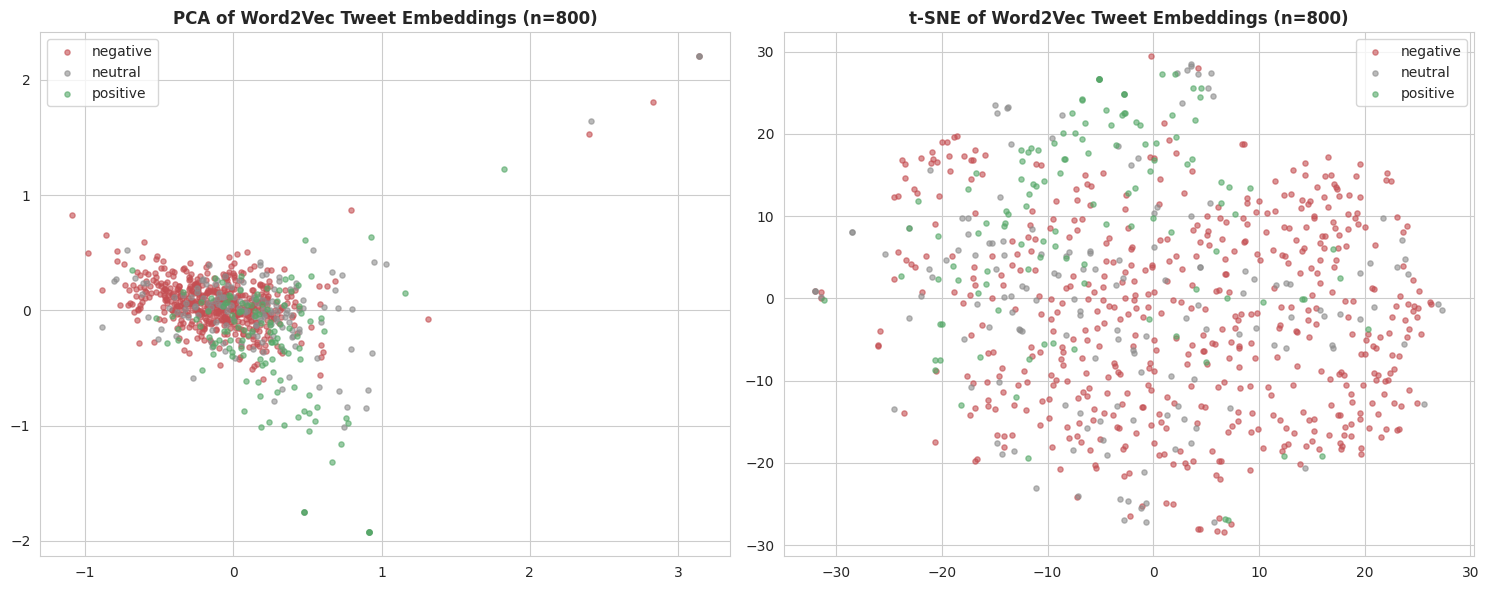

In [66]:
#PCA and t-SNE (800-tweet sample)
idx = np.random.RandomState(42).choice(len(w2v_df), size=800, replace=False)
vecs, labs = vec_matrix[idx], w2v_df['airline_sentiment'].values[idx]
pca = PCA(n_components=2, random_state=42)
pca_xy  = pca.fit_transform(vecs)
tsne_xy = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(vecs)
print('PCA explained variance:', pca.explained_variance_ratio_.round(3))

colors = {'negative':'#C44E52', 'neutral':'#8C8C8C', 'positive':'#55A868'}
fig, axes = plt.subplots(1, 2, figsize=(15,6))
for ax, xy, title in [(axes[0], pca_xy, 'PCA'), (axes[1], tsne_xy, 't-SNE')]:
    for lab, col in colors.items():
        m = labs == lab
        ax.scatter(xy[m,0], xy[m,1], s=14, alpha=0.6, label=lab, color=col)
    ax.set_title(f'{title} of Word2Vec Tweet Embeddings (n=800)', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.show()

In [67]:
#retrieval - find the most similar past tweets for a new complaint
queries = ['the flight was delayed for hours', 'customer service was very unhelpful and rude', 'thank you for the great flight']
rows = []
for q in queries:
    sims = cosine_similarity(sent_vector(tokenize(q), w2v).reshape(1, -1), vec_matrix)[0]
    for rank, i in enumerate(np.argsort(-sims)[:3], 1):
        rows.append({'query': q, 'rank': rank, 'similarity': round(float(sims[i]), 3),
                     'sentiment': w2v_df.loc[i, 'airline_sentiment'], 'retrieved tweet': w2v_df.loc[i, 'text']})
pd.DataFrame(rows)

,query,rank,similarity,sentiment,retrieved tweet
0,the flight was delayed for hours,1,0.967,negative,@united just delayed my flight to SLC by 2.5 hours. What gives? #snowforce
1,the flight was delayed for hours,2,0.929,negative,@SouthwestAir flight 1028 no delayed 1.5 hours. Another week another delayed flight
2,the flight was delayed for hours,3,0.926,negative,@USAirways any update on this flight?It's more than three hours delayed. Thank you.
3,customer service was very unhelpful and rude,1,0.963,negative,@USAirways not impressed with your customer service. everyone has been unhelpful and incredibly rude.
4,customer service was very unhelpful and rude,2,0.930,negative,"@AmericanAir in line at SFO. Customer service is rude, disorganized, and congested. Very dissapointing."
5,customer service was very unhelpful and rude,3,0.922,negative,@united this is very disappointing. This is about customer service.
6,thank you for the great flight,1,0.992,positive,@united thank you for a great flight in gfc :) Cheers http://t.co/nvLnGLnMGN
7,thank you for the great flight,2,0.944,positive,@SouthwestAir Thank you. Great tool
8,thank you for the great flight,3,0.941,positive,@united Joni did a great job on flight 5653 to LAX. Thanks for a great flight.


## Task 4 - Fine-Tuning DistilBERT


In [68]:
#DistilBERT setup
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

device = 'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'
print('Hardware:', device)

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}
bert_df = tweets_df.sample(5000, random_state=42).copy()
bert_df['label'] = bert_df['airline_sentiment'].map(label2id)
train_df, test_df4 = train_test_split(bert_df, test_size=0.2, stratify=bert_df['label'], random_state=42)
print('Train:', len(train_df), '| Test:', len(test_df4))

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tok = lambda b: tokenizer(b['clean_text'], truncation=True, max_length=64)
train_ds = Dataset.from_pandas(train_df[['clean_text','label']]).map(tok, batched=True)
test_ds  = Dataset.from_pandas(test_df4[['clean_text','label']]).map(tok, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params/1e6:.1f}M')

Hardware: GPU: Tesla T4
Train: 4000 | Test: 1000


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 67.0M


In [69]:
#training
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {'accuracy': accuracy_score(labels, preds), 'precision': p, 'recall': r, 'f1': f}

args = TrainingArguments(output_dir='./distilbert', num_train_epochs=3, learning_rate=2e-5,
                         per_device_train_batch_size=16, per_device_eval_batch_size=32, weight_decay=0.01,
                         eval_strategy='epoch', save_strategy='no', logging_steps=50, report_to='none', seed=42)
trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds,
                  data_collator=DataCollatorWithPadding(tokenizer=tokenizer), compute_metrics=compute_metrics)
t0 = time.time()
trainer.train()
bert_time = time.time() - t0
print(f'Training time: {bert_time:.1f}s on {device}')

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.484598,0.472456,0.821000,0.789286,0.737642,0.759787
2,0.375760,0.462353,0.819000,0.777242,0.754138,0.764936
3,0.312506,0.493420,0.822000,0.782031,0.757186,0.768616


Training time: 61.7s on GPU: Tesla T4


Inference time (1,000 tweets): 1.30s
              precision    recall  f1-score   support

    negative      0.872     0.903     0.887       636
     neutral      0.681     0.665     0.673       212
    positive      0.793     0.704     0.746       152

    accuracy                          0.822      1000
   macro avg      0.782     0.757     0.769      1000
weighted avg      0.820     0.822     0.820      1000



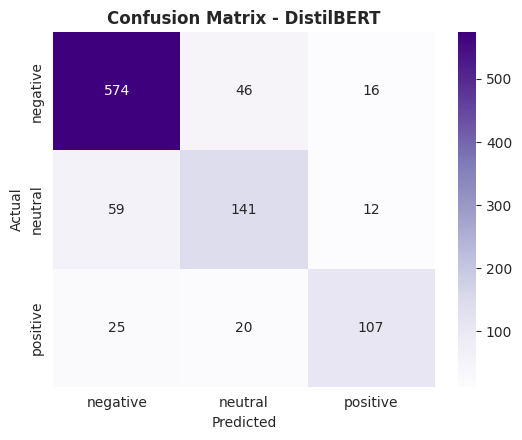

In [70]:
#evaluation
t0 = time.time()
pred_output = trainer.predict(test_ds)
bert_infer = time.time() - t0
y_pred4 = pred_output.predictions.argmax(axis=1)
y_true4 = test_df4['label'].values
print(f'Inference time (1,000 tweets): {bert_infer:.2f}s')
print(classification_report(y_true4, y_pred4, target_names=labels_order, digits=3))

cm_bert = confusion_matrix(y_true4, y_pred4)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples', xticklabels=labels_order, yticklabels=labels_order)
plt.title('Confusion Matrix - DistilBERT', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [71]:
#fair comparison - Logistic Regression on the SAME 4,000 / 1,000 split
tf4 = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2)
Xtr4, Xte4 = tf4.fit_transform(train_df['clean_text']), tf4.transform(test_df4['clean_text'])
t0 = time.time()
lr4 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(Xtr4, train_df['label'])
lr4_time = time.time() - t0
t0 = time.time(); pred_lr4 = lr4.predict(Xte4); lr4_infer = time.time() - t0

def scores(yt, yp):
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average='macro')
    return [f'{accuracy_score(yt, yp):.3f}', f'{p:.3f}', f'{r:.3f}', f'{f:.3f}']

comparison = pd.DataFrame({
    'Aspect': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'Training time',
               'Inference time (1,000 tweets)', 'Model size', 'Interpretability', 'Hardware'],
    'TF-IDF + Logistic Regression': scores(y_true4, pred_lr4) + [f'{lr4_time:.2f}s (CPU)', f'{lr4_infer:.3f}s',
                                     f'{Xtr4.shape[1]*3:,} weights', 'High - feature weights', 'Any CPU'],
    'DistilBERT': scores(y_true4, y_pred4) + [f'{bert_time:.0f}s ({device})', f'{bert_infer:.2f}s',
                   f'{n_params/1e6:.1f}M parameters', 'Low - needs SHAP/LIME', 'GPU recommended']})
comparison

,Aspect,TF-IDF + Logistic Regression,DistilBERT
0,Accuracy,0.786,0.822
1,Precision (macro),0.726,0.782
2,Recall (macro),0.722,0.757
3,F1 (macro),0.724,0.769
4,Training time,3.50s (CPU),62s (GPU: Tesla T4)
5,"Inference time (1,000 tweets)",0.001s,1.30s
6,Model size,"24,000 weights",67.0M parameters
7,Interpretability,High - feature weights,Low - needs SHAP/LIME
8,Hardware,Any CPU,GPU recommended


In [72]:
#do the Task 2 failure cases still fail?
enc = tokenizer([basic_clean(t) for t in EXAMPLES], truncation=True, max_length=64,
                padding=True, return_tensors='pt').to(model.device)
with torch.no_grad():
    ex_probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
for t, pr in zip(EXAMPLES, ex_probs):
    print(f'{id2label[pr.argmax()]:8s} (conf {pr.max():.2f}) | {t}')

neutral  (conf 0.94) | @united flying tomorrow from mexico to US. Mileage tkts dont show 1k status. Help
negative (conf 0.98) | @USAirways Thanks again for ruiningmy vacation.  You all are the best for this.  Could not have done it without you.
negative (conf 0.98) | @SouthwestAir I have been on hold for over 28 minutes  please help http://t.co/Fx9BIJlxAt


## Task 5 - Responsible NLP: Evidence for the Risk Discussion



In [73]:
#error direction - does each model miss complaints or raise false alarms?
def error_direction(m, name):
    missed = (m[0,1] + m[0,2]) / m[0].sum()
    false_alarm = (m[1,0] + m[2,0]) / m[1:].sum()
    print(f'{name:20s}: misses {missed:.1%} of negative tweets | flags {false_alarm:.1%} of non-negative tweets as negative')
error_direction(cm_lr, 'Logistic Regression')
error_direction(cm_bert, 'DistilBERT')

Logistic Regression : misses 18.2% of negative tweets | flags 16.1% of non-negative tweets as negative
DistilBERT          : misses 9.7% of negative tweets | flags 23.1% of non-negative tweets as negative


In [74]:
#abusive language and personal information in the tweets
abuse = r'\b(?:fuck\w*|shit\w*|damn\w*|crap|wtf|stupid|idiot\w*|suck\w*|pathetic|ridiculous)\b'
has_abuse = tweets_df['text'].str.contains(abuse, case=False, regex=True)
print(f'Tweets with profanity/insults: {has_abuse.sum()} ({has_abuse.mean():.1%})')
print(tweets_df.loc[has_abuse, 'airline_sentiment'].value_counts().to_string())

pii = tweets_df['text'].str.contains(r'\b(?![A-Z]{2}\d{3,4}\b)(?=[A-Z0-9]*\d)(?=[A-Z0-9]*[A-Z])[A-Z0-9]{6}\b'
                                     r'|\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b|\S+@\S+\.\w+', regex=True)
print(f'\nTweets with booking codes / phone numbers / emails: {pii.sum()} ({pii.mean():.1%})')
print(f'Tweets with GPS coordinates: {tweets_df_original["tweet_coord"].notna().mean():.1%}')

Tweets with profanity/insults: 393 (2.7%)
airline_sentiment
negative    377
neutral       9
positive      7

Tweets with booking codes / phone numbers / emails: 112 (0.8%)
Tweets with GPS coordinates: 7.0%


 % to human review  % of errors caught  accuracy on auto-handled
                 0                 0.0                     0.784
                10                24.4                     0.819
                20                45.8                     0.854
                30                61.1                     0.880
                40                73.5                     0.905
                50                83.4                     0.929


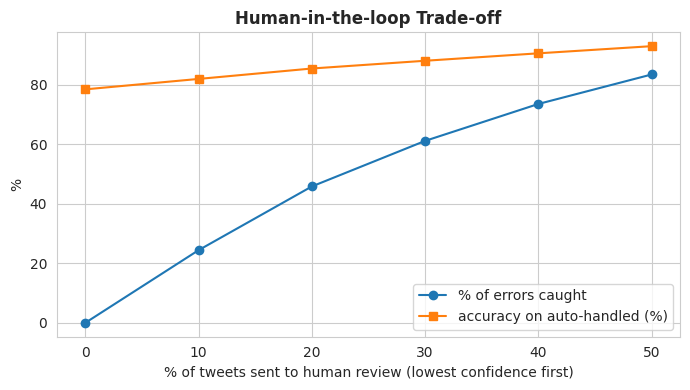

In [75]:
#human-in-the-loop simulation - send the least-confident predictions to a reviewer
hitl_df = test_df.copy()
hitl_df['error'] = hitl_df['true'] != hitl_df['pred']
rows = []
for frac in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    review = hitl_df['confidence'] <= hitl_df['confidence'].quantile(frac) if frac > 0 else pd.Series(False, index=hitl_df.index)
    rows.append({'% to human review': int(frac*100),
                 '% of errors caught': round(hitl_df.loc[review, 'error'].sum() / hitl_df['error'].sum() * 100, 1),
                 'accuracy on auto-handled': round(1 - hitl_df.loc[~review, 'error'].mean(), 3)})
hitl = pd.DataFrame(rows)
print(hitl.to_string(index=False))

plt.figure(figsize=(7,4))
plt.plot(hitl['% to human review'], hitl['% of errors caught'], marker='o', label='% of errors caught')
plt.plot(hitl['% to human review'], hitl['accuracy on auto-handled'] * 100, marker='s', label='accuracy on auto-handled (%)')
plt.xlabel('% of tweets sent to human review (lowest confidence first)'); plt.ylabel('%')
plt.title('Human-in-the-loop Trade-off', fontweight='bold'); plt.legend()
plt.tight_layout()
plt.show()

In [76]:
#is the implicit complaint caught? + rule-based urgency flag
thr20 = hitl_df['confidence'].quantile(0.2)
help_conf = score_with_lr(EXAMPLES[:1])['confidence'].iloc[0]
print(f'20% review threshold = {thr20:.3f} | "...Help" tweet confidence = {help_conf:.3f} ->',
      'caught' if help_conf <= thr20 else 'NOT caught (confidently wrong)')

urgency = r'\b(?:immediately|asap|urgent\w*|stranded|emergency|still waiting|no one|nobody|help)\b'
missed = hitl_df[(hitl_df['true'] == 'negative') & (hitl_df['pred'] != 'negative') & (hitl_df['confidence'] > thr20)]
print(f'Complaints missed and not reviewed: {len(missed)} | caught by urgency rule: '
      f'{missed["text"].str.contains(urgency, case=False, regex=True).sum()}')

20% review threshold = 0.525 | "...Help" tweet confidence = 0.870 -> NOT caught (confidently wrong)
Complaints missed and not reviewed: 174 | caught by urgency rule: 10


In [77]:
#Summary
lr_f1 = results_df.loc['Logistic Regression', 'F1 (macro)']
print('SUMMARY OF FINDINGS')
print(f'Dataset: {len(tweets_df):,} tweets after removing duplicates; '
      f'{(tweets_df["airline_sentiment"] == "negative").mean():.1%} negative')
print(f'Neutral labels with low annotator confidence: {low_conf["neutral"]:.1%}')
print(f'Task 2 - Logistic Regression: accuracy={accuracy_score(y_test, pred_lr):.3f}, macro-F1={lr_f1:.3f}')
print(f'Task 4 - same 1,000 tweets: LR macro-F1={comparison.iloc[3,1]} vs DistilBERT macro-F1={comparison.iloc[3,2]}')
print(f'Task 5 - reviewing 20% of tweets catches {hitl.loc[2, "% of errors caught"]}% of errors')
print()
print('Removing stop words hurts sentiment (negations are deleted), so TF-IDF keeps them.')
print('Word2Vec captures topic, not sentiment - good for retrieval, weak for polarity.')
print('Both models can be confidently wrong, so human review needs extra rule-based checks.')

SUMMARY OF FINDINGS
Dataset: 14,427 tweets after removing duplicates; 62.9% negative
Neutral labels with low annotator confidence: 47.4%
Task 2 - Logistic Regression: accuracy=0.784, macro-F1=0.743
Task 4 - same 1,000 tweets: LR macro-F1=0.724 vs DistilBERT macro-F1=0.769
Task 5 - reviewing 20% of tweets catches 45.8% of errors

Removing stop words hurts sentiment (negations are deleted), so TF-IDF keeps them.
Word2Vec captures topic, not sentiment - good for retrieval, weak for polarity.
Both models can be confidently wrong, so human review needs extra rule-based checks.
